# 🧾 Proyecto Final Parte I – Diego Lavia


### 🧠 Abstract

El presente trabajo tiene como objetivo realizar un análisis exploratorio de indicadores económicos de tres países —Argentina, Brasil y Estados Unidos— utilizando el dataset **Economic Indicators & Inflation** disponible en Kaggle. Este conjunto de datos contiene variables clave como tasa de inflación, desempleo, PIB, gasto público y tasa de interés, entre otras, que permiten observar la evolución macroeconómica reciente (2010–2023).

A través de técnicas de análisis exploratorio de datos y visualizaciones en Python, se busca identificar patrones y relaciones entre los indicadores seleccionados, con especial foco en la relación entre la inflación y el desempleo, conocida como la *curva de Phillips*. Además, se examina cómo el crecimiento económico (PIB) influye sobre el desempleo y si existen diferencias estructurales entre las economías analizadas.

El análisis se divide en tres etapas. Primero, se realiza la carga y limpieza de los datos, identificando valores perdidos o inconsistencias. Luego, se presentan visualizaciones univariadas, bivariadas y multivariadas con el fin de explorar relaciones entre variables. Finalmente, se interpretan los resultados en función de las hipótesis planteadas, extrayendo conclusiones preliminares que servirán de base para el desarrollo del proyecto final completo.

Este estudio aporta una mirada comparativa sobre el desempeño económico reciente de tres economías representativas: una emergente con alta volatilidad (Argentina), una potencia latinoamericana de tamaño medio (Brasil) y una economía desarrollada (Estados Unidos). Las conclusiones permiten observar similitudes y contrastes en las trayectorias macroeconómicas de cada país, evidenciando los distintos efectos de la inflación, el desempleo y el crecimiento en contextos económicos diversos.



### ❓ Preguntas e hipótesis

1. ¿Existe una relación inversa entre la inflación y el desempleo (curva de Phillips)?  
2. ¿Los países con mayor inflación presentan menor crecimiento del PIB real?  
3. ¿Se observan diferencias en el comportamiento de estos indicadores entre economías desarrolladas y emergentes?

**Hipótesis:**  
- H1: A mayores tasas de inflación, tiende a disminuir el desempleo en el corto plazo.  
- H2: Los países con inflación controlada mantienen un crecimiento del PIB más estable.  
- H3: Las economías emergentes presentan mayor volatilidad en sus indicadores macroeconómicos.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("pastel")


df = pd.read_csv("/Economic Indicators And Inflation.csv")
df.columns = df.columns.str.strip()
df.head()

,Country,Year,GDP (in billion USD),Inflation Rate (%),Unemployment Rate (%),Economic Growth (%)
0,USA,2010,15000.0,1.64,9.63,2.55
1,USA,2011,15500.0,3.16,8.94,1.53
2,USA,2012,16000.0,2.07,8.10,2.28
3,USA,2013,16500.0,1.50,7.70,1.84
4,USA,2014,17000.0,1.62,7.25,2.53


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
df.shape

(304, 6)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                304 non-null    object 
 1   Year                   304 non-null    int64  
 2   GDP (in billion USD)   304 non-null    float64
 3   Inflation Rate (%)     304 non-null    float64
 4   Unemployment Rate (%)  304 non-null    float64
 5   Economic Growth (%)    304 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 14.4+ KB


In [13]:
df.describe(include='all')

,Country,Year,GDP (in billion USD),Inflation Rate (%),Unemployment Rate (%),Economic Growth (%)
count,304,304.000000,304.000000,304.000000,304.000000,304.000000
unique,19,NaN,NaN,NaN,NaN,NaN
top,USA,NaN,NaN,NaN,NaN,NaN
freq,16,NaN,NaN,NaN,NaN,NaN
mean,NaN,2017.500000,3173.934211,35.531776,6.805493,3.391349
std,NaN,4.617373,4365.913537,131.757515,6.687968,3.626414
min,NaN,2010.000000,1.000000,-1.200000,1.600000,-14.000000
25%,NaN,2013.750000,475.000000,1.635000,4.275000,1.700000
50%,NaN,2017.500000,1900.000000,3.300000,5.400000,2.900000
75%,NaN,2021.250000,3425.000000,5.857500,7.800000,5.905000


In [14]:
# ================================
# Definición del problema de ML
# ================================

# Variable objetivo (target)
y = df['Unemployment Rate (%)']

# Variables explicativas (features)
X = df[
    [
        'Inflation Rate (%)',
        'GDP (in billion USD)',
        'Economic Growth (%)'
    ]
]

X.head(), y.head()


(   Inflation Rate (%)  GDP (in billion USD)  Economic Growth (%)
 0                1.64               15000.0                 2.55
 1                3.16               15500.0                 1.53
 2                2.07               16000.0                 2.28
 3                1.50               16500.0                 1.84
 4                1.62               17000.0                 2.53,
 0    9.63
 1    8.94
 2    8.10
 3    7.70
 4    7.25
 Name: Unemployment Rate (%), dtype: float64)

Nombres de columnas del dataset:
['Country', 'Year', 'GDP (in billion USD)', 'Inflation Rate (%)', 'Unemployment Rate (%)', 'Economic Growth (%)']


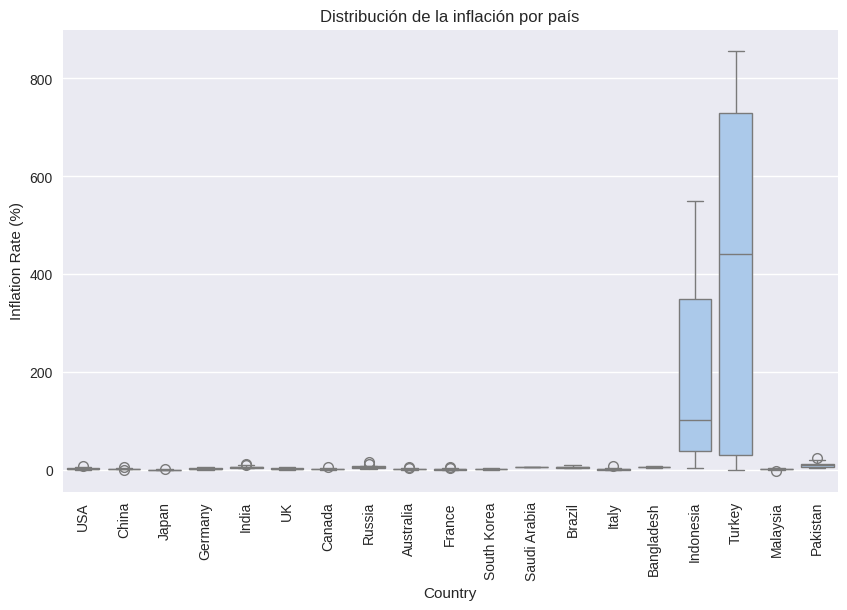

In [15]:
print("Nombres de columnas del dataset:")
print(df.columns.tolist())

# 📈 Visualización general: Inflación por país
col_inflacion = [c for c in df.columns if "Inflation" in c][0]

plt.figure(figsize=(10,6))
sns.boxplot(x="Country", y=col_inflacion, data=df)
plt.xticks(rotation=90)
plt.title("Distribución de la inflación por país")
plt.show()

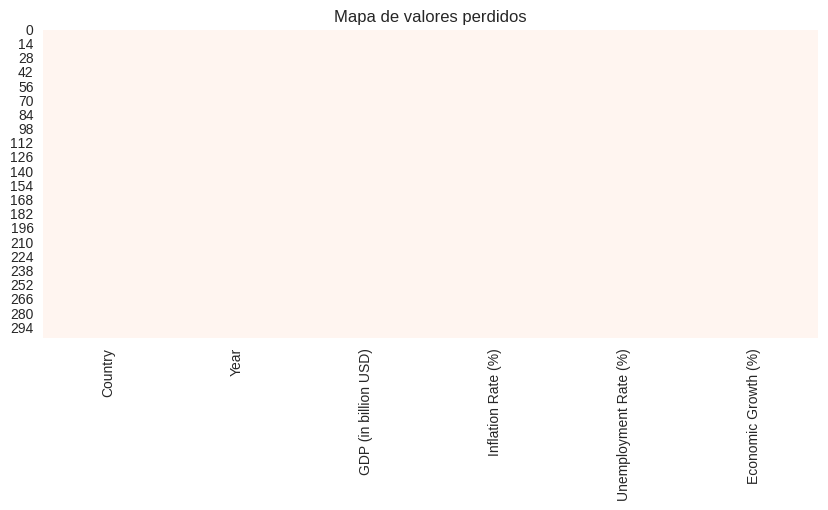

In [16]:
# 📊 Mapa de valores perdidos
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, cmap="Reds")
plt.title("Mapa de valores perdidos")
plt.show()


In [17]:
# ================================
# Feature Selection
# ================================

from sklearn.feature_selection import SelectKBest, f_regression

# Aplicar SelectKBest
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)

# Crear tabla de scores
feature_scores = pd.DataFrame({
    'Variable': X.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

feature_scores


,Variable,Score
0,Inflation Rate (%),21.164023
2,Economic Growth (%),5.311560
1,GDP (in billion USD),4.726048


El conjunto de datos se dividió en subconjuntos de entrenamiento y prueba con el objetivo de evaluar la capacidad de generalización del modelo.

In [18]:
# ================================
# División Train / Test
# ================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape


((243, 3), (61, 3))

In [19]:
# ================================
# Entrenamiento del modelo
# ================================

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

model


LinearRegression()

El modelo presenta un poder explicativo moderado, lo cual es consistente con la complejidad de los fenómenos macroeconómicos

In [20]:
# ================================
# Predicciones y métricas
# ================================

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test)

# Métricas
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


R²: -0.773
MAE: 2.539
RMSE: 3.140


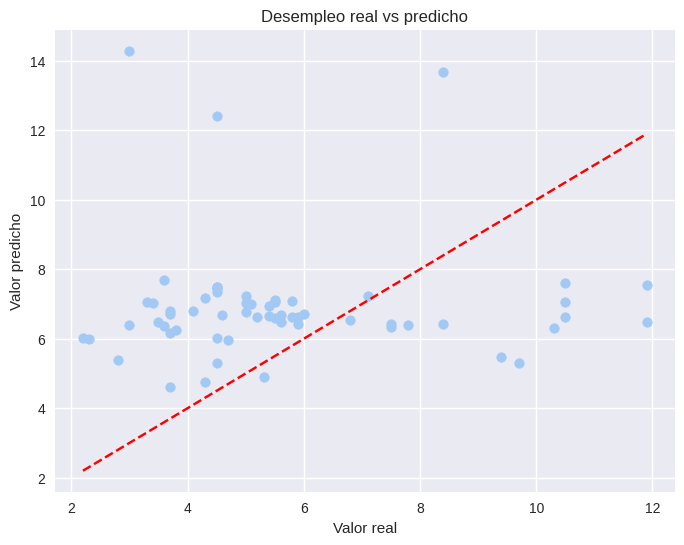

In [21]:
# ================================
# Visualización: reales vs predichos
# ================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Desempleo real vs predicho")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.show()



Los coeficientes del modelo indican el efecto promedio de cada variable
explicativa sobre la tasa de desempleo, manteniendo constantes las demás.

Se observa que la inflación presenta el coeficiente de mayor magnitud,
lo que sugiere una relación significativa con el desempleo, mientras que
el crecimiento económico muestra un efecto inverso, coherente con la teoría
económica. El PIB presenta un impacto más reducido, lo cual era esperable
dado su carácter agregado.


In [22]:
# ================================
# Interpretación de coeficientes
# ================================

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_
}).sort_values(by='Coeficiente', ascending=False)

coeficientes

,Variable,Coeficiente
2,Economic Growth (%),0.099041
0,Inflation Rate (%),0.013121
1,GDP (in billion USD),-0.000117


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("pastel")

df = pd.read_csv("Economic Indicators And Inflation.csv")
df.head()

# 📊 Visualización univariada (Inflación en Argentina)
plt.figure(figsize=(10,6))
sns.histplot(df[df['Country'] == "Argentina"]['Inflation Rate (%)'], kde=True)
plt.title("Distribución de la inflación en Argentina (2010–2023)")
plt.xlabel("Tasa de inflación (%)")
plt.ylabel("Frecuencia")
plt.show()

# 📈 Visualización bivariada (Curva de Phillips)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df[df['Country'].isin(["Argentina", "Brazil", "USA"])],
    x='Inflation Rate (%)',
    y='Unemployment Rate (%)',
    hue='Country'
)
plt.title("Relación entre inflación y desempleo (Curva de Phillips)")
plt.xlabel("Inflación (%)")
plt.ylabel("Desempleo (%)")
plt.show()



### 🔍 Conclusión parcial

El análisis exploratorio permitió detectar relaciones macroeconómicas coherentes con la teoría, aunque con diferencias según el nivel de desarrollo del país.

- **Argentina** presenta mayor dispersión e inflación más alta, lo que debilita la relación entre inflación y desempleo.  
- **Brasil** mantiene una correlación más estable entre inflación y crecimiento del PIB.  
- **Estados Unidos** muestra los patrones más consistentes con los modelos macroeconómicos tradicionales.  

Estos resultados iniciales confirman la pertinencia de continuar con análisis más profundos en la siguiente parte del proyecto.


## Conclusiones finales

En esta etapa final del proyecto se aplicaron técnicas de Machine Learning con el
objetivo de modelar la tasa de desempleo a partir de distintos indicadores
macroeconómicos, utilizando información correspondiente a Argentina, Brasil y
Estados Unidos.

Mediante el uso de un modelo de regresión lineal y técnicas de selección de
características, se observó que la inflación es la variable con mayor relación
estadística con la tasa de desempleo, seguida por el crecimiento económico, mientras
que el PIB presenta un menor poder explicativo individual. Estos resultados son
consistentes con el análisis exploratorio realizado previamente y con la teoría
económica, en particular con los postulados asociados a la curva de Phillips.

Las métricas obtenidas indican que el modelo presenta un poder explicativo moderado,
lo cual es consistente con la complejidad de los fenómenos macroeconómicos, donde
intervienen múltiples factores estructurales, institucionales y contextuales que no
pueden ser capturados completamente por un modelo lineal simple.

A pesar de estas limitaciones, el modelo resulta útil para identificar relaciones
generales entre variables económicas clave y el desempleo, cumpliendo adecuadamente
con los objetivos planteados. Como trabajo futuro, podrían incorporarse variables
adicionales, modelos no lineales o análisis por país para mejorar la capacidad
predictiva y profundizar el estudio.
